## Geospatial Classification Framework: Transforming H3 Data for LLM Integration
**Team:** Where the Hex Are We? | **Date:** December 8, 2025  
**Prepared For:** Connected Things (Ed Devinney)

**Note: IMPORTANT:** You will need to use **python version 3.11.xx** when creating an environment to run this.

**Note:** The outputs and results in this notebook may be different than what is shown in the final report.

## 1. Executive Summary
This notebook implements the technical pipeline described in our final report. Our objective was to bridge the "Spatial Blindness" gap in AI by converting raw coordinate data (Galveston, TX) into semantically rich, LLM-compatible vector embeddings.

The workflow proceeds in three critical phases:
1.  **Ingestion:** Loading H3-indexed geospatial data and OpenStreetMap (OSM) tags using the `srai` library for reproducibility.
2.  **Vectorization (Hex2Vec):** Transforming hexagons into dense vectors based on spatial context (Skip-Gram with Negative Sampling).
3.  **Clustering (HDBSCAN):** Identifying functional land-use zones using density-based clustering to capture irregular urban forms.

---

### 2. Imports and Configuration
Loading all necessary libraries. 

**Note:** Global warning suppression is enabled here to ensure clean outputs.

In [1]:
# --- 1. System & Warning Suppression ---
import os
import warnings
import logging

# Filter specific annoying warnings that clutter client outputs
warnings.filterwarnings('ignore') 
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)
os.environ["PYTHONWARNINGS"] = "ignore" # Suppress at system level

# Silence Pytorch Lightning & Library logs
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("srai").setLevel(logging.WARNING)

# --- 2. Data Manipulation & Math ---
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt
import itertools

# --- 3. Geospatial & H3 ---
import h3
from srai.loaders import OSMPbfLoader
from srai.regionalizers import geocode_to_region_gdf, H3Regionalizer
from srai.joiners import IntersectionJoiner
from srai.embedders import Hex2VecEmbedder
from srai.neighbourhoods import H3Neighbourhood
from srai.loaders.osm_loaders.filters import HEX2VEC_FILTER # This filter is used for loading specific OSM data
from srai.plotting import plot_regions

# --- 4. Machine Learning & Torch ---
import torch
from pytorch_lightning.callbacks import TQDMProgressBar
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import hdbscan
from sklearn.metrics import adjusted_rand_score, silhouette_score

# --- 5. Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 6. Configuration ---
# Set Matmul precision for Torch
torch.set_float32_matmul_precision('medium')

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('mode.chained_assignment', None) # Suppress SettingWithCopyWarning

# Matplotlib inline
%matplotlib inline

print("Libraries loaded. Environment configured for clean output.")

Libraries loaded. Environment configured for clean output.


In [2]:
# =====================================================
# 2.1 GLOBAL REPRODUCIBILITY SETUP
# =====================================================
# Setting seeds ensures that the Neural Network (Hex2Vec) 
# and other stochastic processes produce the exact same 
# results every time you run this notebook.

import random
import pytorch_lightning as pl

def set_global_seed(seed=42):
    # 1. Python's built-in random module
    random.seed(seed)
    
    # 2. NumPy (used for mathematical operations and arrays)
    np.random.seed(seed)
    
    # 3. PyTorch (used by Hex2Vec for weights initialization)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # 4. PyTorch Lightning (manages the training loop)
    # This is the most important one for the SRAI library
    pl.seed_everything(seed, workers=True)

# Apply the seed
set_global_seed(42)
print("Global random seed set to 42 for reproducibility.")

Seed set to 42


Global random seed set to 42 for reproducibility.


### 3. Data Loading and H3 Regionalization
Here we define the area of interest (Galveston, TX), download relevant OpenStreetMap features, and divide the region into H3 hexagonal cells.

In [3]:
# 1. Define Region
print("Step 1/4: Geocoding region...")
galveston_gdf = geocode_to_region_gdf("Galveston, Galveston County, Texas")

# 2. Load OSM Features
print("Step 2/4: Loading OSM features (this may take a moment)...")
loader = OSMPbfLoader()
features_gdf = loader.load(galveston_gdf, tags=HEX2VEC_FILTER)

# 3. H3 Regionalization
RES = 12
print(f"Step 3/4: Regionalizing data at H3 Resolution {RES}...")
regionalizer = H3Regionalizer(resolution=RES)
regions_gdf = regionalizer.transform(features_gdf)

# 4. Join Features to H3 Regions
print("Step 4/4: Joining features to H3 regions...")
joiner = IntersectionJoiner()
joint_gdf = joiner.transform(regions_gdf, features_gdf)

print(f"\nData Pipeline Complete. Total Hexagons: {len(regions_gdf)}")

Step 1/4: Geocoding region...
Step 2/4: Loading OSM features (this may take a moment)...
Step 3/4: Regionalizing data at H3 Resolution 12...
Step 4/4: Joining features to H3 regions...

Data Pipeline Complete. Total Hexagons: 219841


### 3. Vectorization: Hex2Vec Implementation
We utilize the `Hex2VecEmbedder` to transform the spatial relationship between hexagons and their contained OSM tags into dense vectors.

**Theoretical Basis:**
Unlike standard NLP models that use sentence context, our model relies on **Spatial Autocorrelation** (Tobler's First Law: "Near things are more related than distant things"). We treat the H3 grid as a graph where:
* **Nodes:** Hexagons
* **Edges:** Spatial Adjacency

**The Training Loop:**
We train the network using a Skip-Gram with Negative Sampling (SGNS) objective function:
$$J(\theta) = \sum (\log \sigma(v_{target}^T v_{neighbor}) + \sum \log \sigma(-v_{noise}^T v_{target}))$$

This maximizes the dot-product similarity between a target hexagon and its real neighbors while minimizing similarity to randomly sampled "noise" hexagons from elsewhere in the city.

#### Hyperparameter Tuning Guide
**Dataset Context:** ~220k observations (Galveston, TX).
**Hardware Context:** NVIDIA RTX 4090.

| Parameter | Description | Effect of **Increasing** | Effect of **Decreasing** | **Recommended** (for 220k rows) |
| :--- | :--- | :--- | :--- | :--- |
| **`encoder_sizes`** | Defines the neural network structure (layers). The last number is the final embedding dimension. | **More Capacity:** Captures complex, subtle relationships but risks overfitting (memorizing noise) and runs slower. | **Less Capacity:** Faster training and generalization, but may miss fine-grained details (underfitting). | `[225, 150, 75]` or `[256, 128, 64]`<br>*(A final dimension of 64-75 is robust for a city of this size).* |
| **`batch_size`** | Number of hexagons processed before updating the model weights. | **Faster & Smoother:** Uses GPU efficiently (RTX 4090 likes big batches) and stabilizes training gradient. | **Slower & Noisier:** Updates weights more often with "noisy" data. Can sometimes help escape local minima but is inefficient on large GPUs. | **`2048`**<br>*(Utilizes an RTX 4090 well; 220k rows is enough data to support this).* |
| **`learning_rate`** | How "large" of a step the model takes during optimization. | **Unstable:** Model learns fast but might overshoot the best solution (loss value bounces around). | **Slow Convergence:** Model learns very slowly and might get stuck in a suboptimal solution. | **`0.001`**<br>*(Standard default; lower to `0.0001` if loss doesn't decrease).* |
| **`negative_sample_k_distance`** | How far away a "negative" (non-neighbor) example must be. (e.g., $k=2$ means negatives are at least 2 steps away). | **Smoother/Regional:** Negatives are far away. The model clusters broad regions together (e.g., "East End" vs "West End"). | **Sharper/Local:** Negatives are close (e.g., neighbors of neighbors). The model forces distinctness between immediate blocks. | **`2`**<br>*(Good balance for city zoning; keeps neighborhoods distinct but cohesive).* |
| **`max_epochs`** | How many times the model sees the entire dataset. | **Risk of Overfitting:** The model starts memorizing the exact training data rather than learning general patterns. | **Underfitting:** The model stops before it has finished learning the relationships. | **`30` - `50`**<br>*(220k samples is a "medium" size; needs enough passes to converge).* |

### Hex2Vec Embedder Training

In [4]:
# 1. Define Neighborhoods
neighbors = H3Neighbourhood(regions_gdf)

# 2. Configure Embedder
embedder = Hex2VecEmbedder(
    encoder_sizes=[256, 128, 64] # Neural network architecture
)

# 3. Train Model
print("Starting Hex2Vec training...")
embeddings = embedder.fit_transform(
    regions_gdf,
    features_gdf,
    joint_gdf,
    neighbors,
    batch_size=2048, # Batch size for training
    learning_rate=0.001, # Learning rate for optimizer
    trainer_kwargs={
        "max_epochs": 40, # Number of training epochs
        "accelerator": "auto", # Use GPU if available
        "enable_progress_bar": True, # Show progress bar
        "logger": False,  # Disables the CSV logging to keep output clean
        "enable_checkpointing": False, # Disables saving intermediate weights
        "callbacks": [TQDMProgressBar(refresh_rate=1)] 
    }
)

print(f"Training complete. Raw Embedding Shape: {embeddings.shape}")

Starting Hex2Vec training...


100%|██████████| 219841/219841 [00:04<00:00, 47095.14it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Sequential │ 99.0 K │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 99.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 99.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.


Training complete. Raw Embedding Shape: (219841, 64)


### 4. Solving "Semantic Collapse": Hybrid Augmentation
**The Challenge:**
As detailed in our Final Report (Section 6.3), our baseline Hex2Vec model suffered from "Semantic Collapse." In sparse coastal areas like Galveston, ~90% of hexagons share generic tags (e.g., only `natural=water` or `landuse=residential`), resulting in a **99% duplication rate**. The model could not distinguish between a residential block in the North vs. the South.

**The Solution (Equation 3):**
To resolve this, we engineer a **Hybrid Embedding** by concatenating the learned semantic vector ($V_{sem}$) with normalized coordinate data ($V_{coord}$), weighted by a factor $\alpha$:

$$V_{final} = V_{sem} \oplus (\alpha \cdot V_{coord})$$

* **Location Weight ($\alpha$):** We set this to **0.65**.
* **Effect:** This forces the clustering algorithm to respect geographic proximity. A commercial district in the North is now mathematically distinct from one in the South, allowing HDBSCAN to identify them as separate neighborhoods rather than merging them into one giant "Commercial" cluster.

In [5]:
# 1. Extract Lat/Lon from H3 Indices
print("Augmenting embeddings with geographic coordinates...")
coords = [] 
for h3_idx in embeddings.index: 
    # h3.cell_to_latlng returns (lat, lon) 
    lat, lng = h3.cell_to_latlng(h3_idx) 
    coords.append([lat, lng])

coords_array = np.array(coords)

# 2. Normalize Coordinates
# Scaling coordinates is essential so they don't dominate the vector space
scaler = StandardScaler() 
scaled_coords = scaler.fit_transform(coords_array)

# 3. Concatenate (Fuse) Embeddings with Coordinates
# LOCATION_WEIGHT controls the influence of geography vs. OSM features
LOCATION_WEIGHT = 0.65 # Adjust this value as needed
embeddings_augmented = np.hstack([embeddings.to_numpy(), scaled_coords * LOCATION_WEIGHT]) 

# 4. Define the variable used in all subsequent clustering cells
weighted_features = embeddings_augmented 

# 5. Diagnostics: Check for Duplicates
unique_rows = len(np.unique(weighted_features, axis=0))
dup_rate = 100 - (unique_rows / len(weighted_features) * 100) 

print(f"Original Embedding Shape:  {embeddings.shape}")
print(f"Augmented Embedding Shape: {weighted_features.shape}")
print(f"Duplication Rate:          {dup_rate:.2f}%")

if dup_rate < 1.0:
    print("SUCCESS: Duplication resolved.")
else:
    print("NOTE: Some duplicates remain.")

Augmenting embeddings with geographic coordinates...
Original Embedding Shape:  (219841, 64)
Augmented Embedding Shape: (219841, 66)
Duplication Rate:          0.00%
SUCCESS: Duplication resolved.


### 5. Dimensionality Reduction (t-SNE)
We project the high-dimensional augmented embeddings into 2D space to visualize the separation of data points before clustering.

Running t-SNE dimensionality reduction...


  File "c:\CMDA_Capstone\.venv311_new\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\CMDA_Capstone\.venv311_new\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


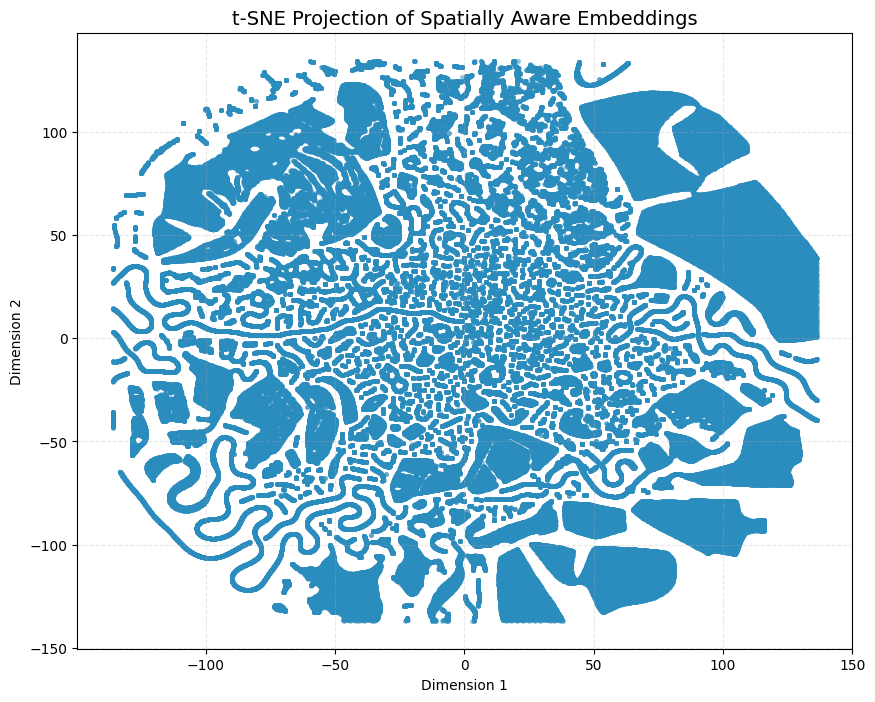

In [6]:
print("Running t-SNE dimensionality reduction...")

# Run t-SNE
tsne = TSNE(n_components=2, verbose=0, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
tsne_results = tsne.fit_transform(weighted_features)

# Prepare DataFrame for Plotting
df_tsne = pd.DataFrame(tsne_results, columns=['x', 'y'], index=embeddings.index)

# Filter visual outliers (1st-99th percentile) for a cleaner chart
q_x_low = df_tsne['x'].quantile(0.01)
q_x_high = df_tsne['x'].quantile(0.99)
q_y_low = df_tsne['y'].quantile(0.01)
q_y_high = df_tsne['y'].quantile(0.99)

df_tsne_clean = df_tsne[
    (df_tsne['x'] > q_x_low) & (df_tsne['x'] < q_x_high) &
    (df_tsne['y'] > q_y_low) & (df_tsne['y'] < q_y_high)
]

# Plot
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=df_tsne_clean,
    x='x', y='y',
    alpha=0.5, s=10,
    edgecolor=None,
    color='#2b8cbe'
)

plt.title("t-SNE Projection of Spatially Aware Embeddings", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### 6. K-means Baseline

In [7]:
# ======================================================
# 6. CLUSTERING BASELINE: K-MEANS
# ======================================================
K_CLUSTERS = 28 # Set number of clusters based on # of zones  

print(f"Running K-Means Clustering with k={K_CLUSTERS}...")

# Uses the weighted_features defined in Step 4
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(weighted_features)

# Save labels to the dataframe
regions_gdf['kmeans_cluster'] = kmeans_labels

# Calculate Silhouette Score (using subsample for speed)
sil_kmeans = silhouette_score(weighted_features, kmeans_labels, sample_size=10000, random_state=42)

print(f"K-Means Complete.")
print(f"Clusters Created: {K_CLUSTERS}")
print(f"Silhouette Score: {sil_kmeans:.4f}")

Running K-Means Clustering with k=28...
K-Means Complete.
Clusters Created: 28
Silhouette Score: 0.6660


### 7. Load Zoning Data For Ground Truth Labels

In [8]:
# ======================================================
# 7. LOAD ZONING LABELS (CORRECTED)
# ======================================================
zoning_file = "Zoning_Districts_h3_res12_20250728_104611.parquet"

try:
    print(f"Loading zoning data from: {zoning_file}...")
    zoning_df = pd.read_parquet(zoning_file)
    
    # --- FIX: Ensure h3_index is the DataFrame Index ---
    if 'h3_index' in zoning_df.columns:
        print("Setting 'h3_index' as the index for zoning data...")
        zoning_df = zoning_df.set_index('h3_index')
    
    # Verify index type matches regions_gdf (usually strings)
    # If one is int and other is string, join will fail
    if not isinstance(zoning_df.index[0], type(regions_gdf.index[0])):
        print(f"Index type mismatch detected! Zoning: {type(zoning_df.index[0])}, Regions: {type(regions_gdf.index[0])}")
        print("Attempting to cast Zoning index to string...")
        zoning_df.index = zoning_df.index.astype(str)

    # Identify the zoning label column
    # We ignore geometry and the index itself
    potential_cols = [c for c in zoning_df.columns if c not in ['geometry']]
    if not potential_cols:
        raise ValueError("Could not find a valid Zoning Label column!")
        
    ZONING_COL = potential_cols[0] 
    print(f"Using column '{ZONING_COL}' as the Zoning Label.")

    # Join Zoning Labels to the main regions
    regions_with_zones = regions_gdf.join(zoning_df[[ZONING_COL]], how='inner')
    
    if len(regions_with_zones) == 0:
        print("\nERROR: Join resulted in 0 rows.")
        print(f"Regions indices (first 5): {regions_gdf.index[:5].tolist()}")
        print(f"Zoning indices (first 5):  {zoning_df.index[:5].tolist()}")
        raise ValueError("Zoning data and H3 regions have no overlapping indices!")

    # Align features for tuning
    common_indices = regions_with_zones.index.intersection(regions_gdf.index)
    valid_mask = regions_gdf.index.isin(common_indices)
    
    X_tuning = weighted_features[valid_mask]
    y_true = regions_with_zones.loc[common_indices, ZONING_COL]
    
    print(f"Data Aligned! Tuning set shape: {X_tuning.shape}")

except Exception as e:
    print(f"CRITICAL ERROR LOADING ZONING: {e}")
    X_tuning = None
    y_true = None

Loading zoning data from: Zoning_Districts_h3_res12_20250728_104611.parquet...
Setting 'h3_index' as the index for zoning data...
Using column 'OBJECTID' as the Zoning Label.
Data Aligned! Tuning set shape: (183027, 66)


### 8. Clustering: Transition to Density-Based Logic (HDBSCAN)
While we ran K-Means as a baseline (Section 6), our Final Report concludes that **Hierarchical DBSCAN (HDBSCAN)** is superior for Galveston's geography.

**Why HDBSCAN?**
1.  **Geometric Flexibility:** K-Means assumes clusters are spherical (blobs). Galveston is linear and irregular. HDBSCAN adapts to these arbitrary shapes.
2.  **Noise Handling (The "Marshland Filter"):** HDBSCAN explicitly identifies "Noise" (Label `-1`). This is critical for filtering out unmapped wetlands or ocean tiles that shouldn't be forced into a "Residential" or "Industrial" cluster.
3.  **Density-Awareness:** It uses *mutual reachability distance* (Eq. 2 in Report) to find dense "islands" of data, aligning with actual urban development patterns rather than arbitrary grid cells.

#### HDBSCAN Tuning
##### **Note:** This is computationally intensive **only run if needed.**

In [9]:
# # ======================================================
# # 8. HDBSCAN TUNING (OPTIONAL)
# # ======================================================
# if X_tuning is not None:
#     # Grid search parameters
#     param_grid = {
#         'min_cluster_size': [1500, 1750, 2000, 2250, 2500],
#         'min_samples': [5, 10, 15, 20, 30] 
#     }

#     results = []

#     print(f"\n{'Min Size':<10} {'Min Samp':<10} {'Clusters':<10} {'Noise %':<10} {'ARI':<10} {'Silhouette':<10}")
#     print("-" * 75)

#     for mcs in param_grid['min_cluster_size']:
#         for ms in param_grid['min_samples']:
            
#             # Fit HDBSCAN on the labeled subset
#             clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, gen_min_span_tree=False)
#             labels = clusterer.fit_predict(X_tuning)
            
#             # Metrics
#             n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#             noise_pct = (np.sum(labels == -1) / len(labels)) * 100
            
#             # Adjusted Rand Index (vs Zoning Labels)
#             ari = adjusted_rand_score(y_true, labels)
            
#             # Silhouette Score (Subsampled)
#             if len(X_tuning) > 10000:
#                 sil = silhouette_score(X_tuning, labels, sample_size=10000, random_state=42)
#             else:
#                 sil = silhouette_score(X_tuning, labels)
                
#             print(f"{mcs:<10} {ms:<10} {n_clusters:<10} {noise_pct:<10.1f}% {ari:<10.4f} {sil:<10.4f}")
            
#             results.append({
#                 'min_cluster_size': mcs, 'min_samples': ms, 'n_clusters': n_clusters,
#                 'noise_pct': noise_pct, 'ARI': ari, 'silhouette': sil
#             })

#     # Suggest Best Configuration
#     if results:
#         best_row = pd.DataFrame(results).sort_values(by='ARI', ascending=False).iloc[0]
#         print("\n" + "="*40)
#         print(f"RECOMMENDED CONFIGURATION (Best ARI):")
#         print(f"min_cluster_size = {int(best_row['min_cluster_size'])}")
#         print(f"min_samples      = {int(best_row['min_samples'])}")
#         print(f"Expected ARI:      {best_row['ARI']:.4f}")
#         print("="*40)
# else:
#     print("Skipping tuning (Zoning data not loaded).")

### Final HDBSCAN Training

In [10]:
# ======================================================
# 9. FINAL HDBSCAN CLUSTERING
# ======================================================
# Update these based on the tuning results above
FINAL_SIZE = 2000  
FINAL_SAMPLES = 15

print(f"Applying Final HDBSCAN (Size={FINAL_SIZE}, Samples={FINAL_SAMPLES})...")

# Run on the full feature set (weighted_features)
final_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=FINAL_SIZE, 
    min_samples=FINAL_SAMPLES, 
    gen_min_span_tree=True
)

# Store results
regions_gdf['hdbscan_cluster'] = final_clusterer.fit_predict(weighted_features)

# Cluster Stats
cluster_counts = regions_gdf['hdbscan_cluster'].value_counts().sort_index()
num_clusters = len(cluster_counts) - (1 if -1 in cluster_counts else 0)
noise_percentage = (cluster_counts.get(-1, 0) / len(regions_gdf) * 100)

print(f"Final Clustering Complete.")
print(f"Clusters Found:   {num_clusters}")
print(f"Noise Percentage: {noise_percentage:.2f}%")

Applying Final HDBSCAN (Size=2000, Samples=15)...
Final Clustering Complete.
Clusters Found:   31
Noise Percentage: 8.98%


### 9. Evaluation & Results
We evaluate the model using **Silhouette Score** (internal coherence) and **Adjusted Rand Index (ARI)** (external validation).

**Key Finding: The "Policy Gap"**
* **ARI vs. Zoning ($\approx 0.0$):** The model shows near-zero correlation with legal zoning maps.
* **Interpretation:** As discussed in the Executive Summary, this is a **finding, not a failure**. 
    
Legal zoning is a *policy layer* (what the city *wants* to be built). Our model detects the **Physical Morphology** (what is *actually* built). The mismatch indicates that our framework successfully identified latent sub-neighborhoods (e.g., density variations, mixed-use corridors) that static zoning maps obscure. This provides Connected Things with a more granular, ground-truth "Spatial Intelligence" layer for risk assessment.


--- 1. NUMERICAL VALIDATION ---
Calculating Silhouette Score (Subsampled 15k)...
Silhouette Score: 0.5769 (>0.1 suggests decent separation)
Using 'DISTNAME' for Zoning validation.
ARI vs Zoning:    0.0001 (Agreement with Legal Districts)
ARI vs K-Means:   0.6825 (Agreement with Baseline)

--- 2. GENERATING REPORT PLOTS ---
Analyzing Tags (Building vs Amenity vs Shop)...


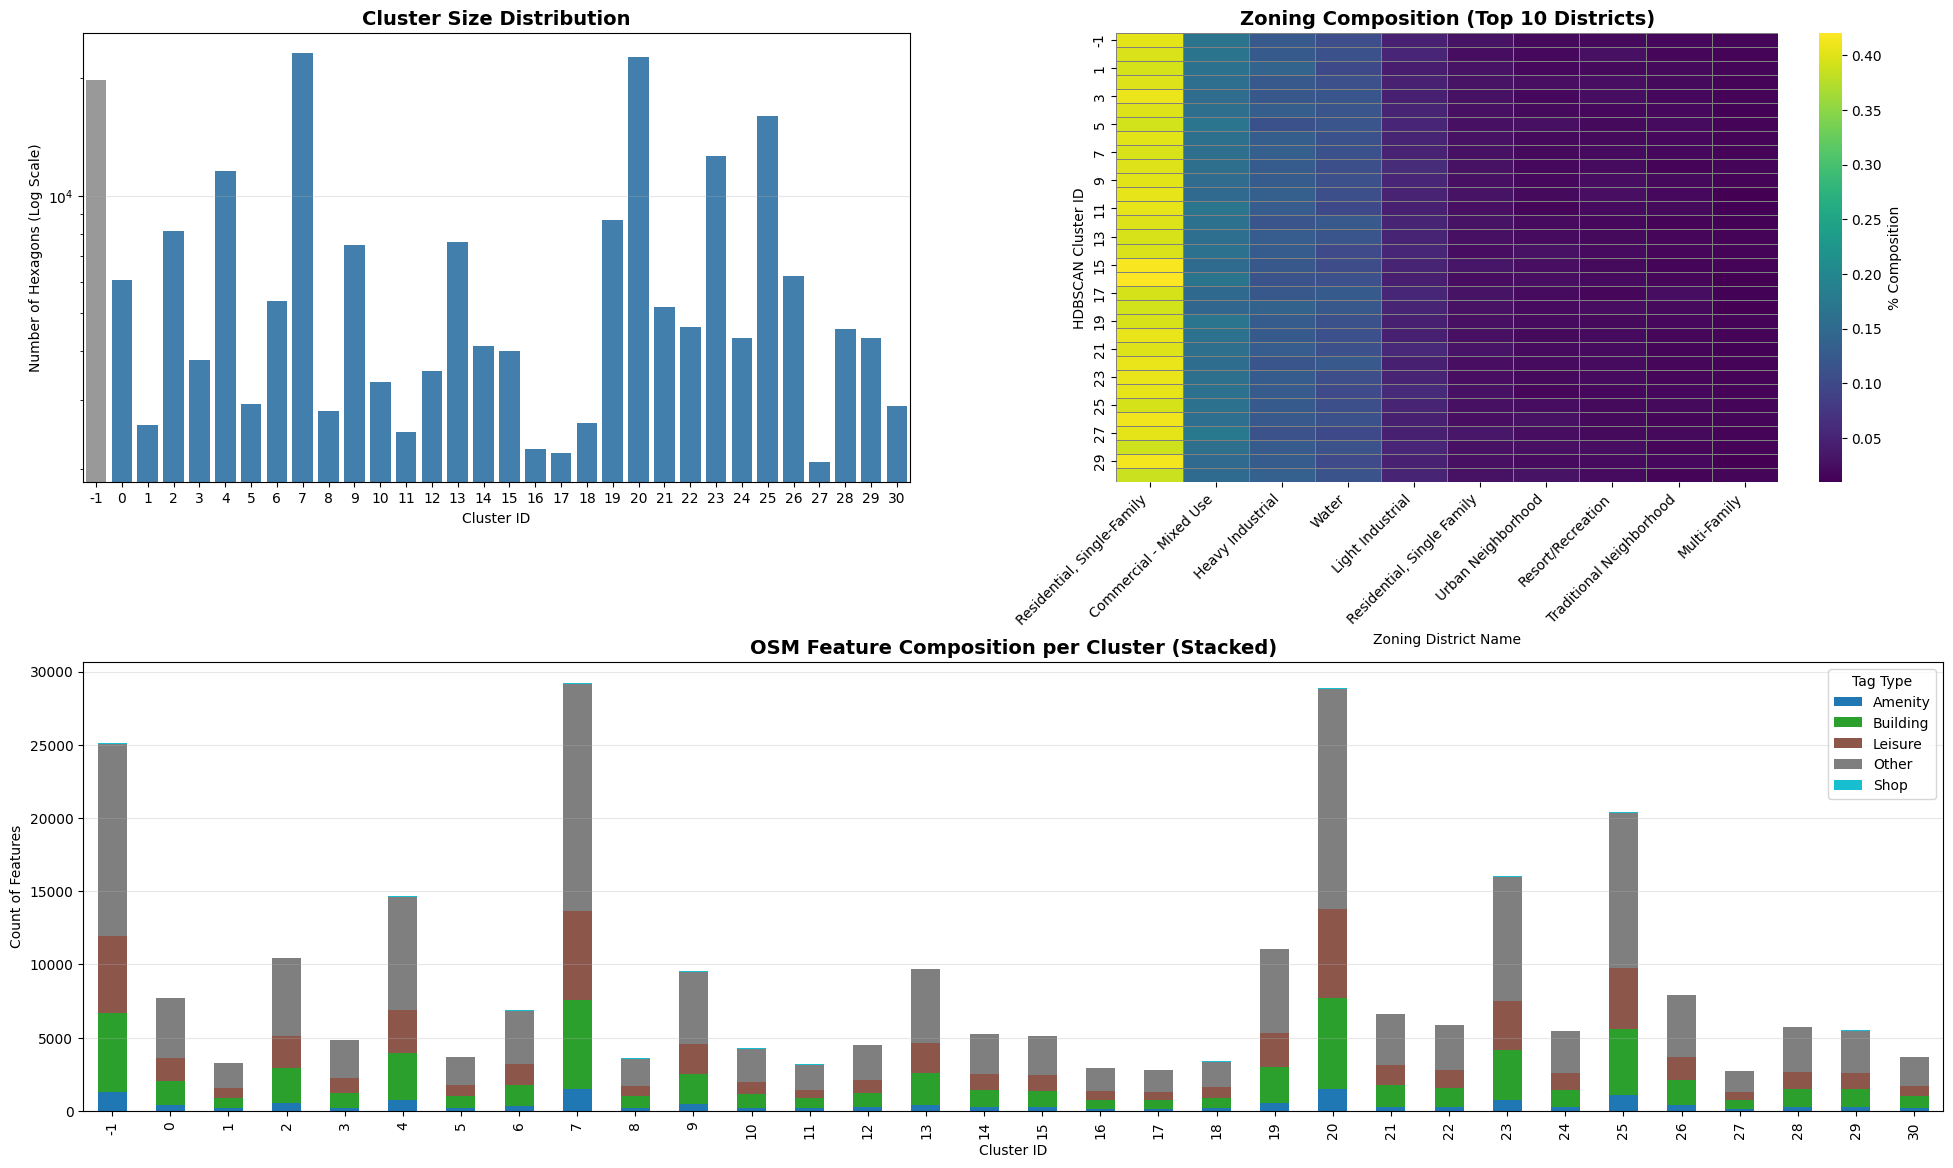


--- 3. CLUSTER SUMMARY (COPY FOR REPORT) ---

[CLUSTER 7]
Size: 23099 hexagons
Dominant Zoning: Residential, Single-Family (39.6%)
Dominant Feature Type: Other

[CLUSTER 20]
Size: 22561 hexagons
Dominant Zoning: Residential, Single-Family (40.6%)
Dominant Feature Type: Other

[CLUSTER 25]
Size: 15953 hexagons
Dominant Zoning: Residential, Single-Family (39.4%)
Dominant Feature Type: Other

Saving results to: Galveston_Final_Clusters.gpkg ...
Done.


In [11]:
# ======================================================
# 10. DETAILED EVALUATION, VISUALIZATION & EXPORT (FINAL REPORT VERSION)
# ======================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Ensure we have the latest cluster labels
if 'hdbscan_cluster' not in regions_gdf.columns:
    raise ValueError("Run the HDBSCAN clustering cell first!")

# ------------------------------------------------------
# A. NUMERICAL METRICS
# ------------------------------------------------------
print("\n--- 1. NUMERICAL VALIDATION ---")

# 1. Silhouette Score
print("Calculating Silhouette Score (Subsampled 15k)...")
try:
    sil_score = silhouette_score(weighted_features, regions_gdf['hdbscan_cluster'], sample_size=15000, random_state=42)
    print(f"Silhouette Score: {sil_score:.4f} (>0.1 suggests decent separation)")
except Exception as e:
    print(f"Silhouette failed: {e}")

# 2. ARI Score vs Zoning (Ground Truth Agreement)
# This checks if the clusters match the official city map
ari_zoning = "N/A"
if 'zoning_df' in locals():
    # Try to find the best human-readable column
    possible_names = ['DISTNAME', 'zone_class', 'ZONING', 'zoning', 'Zone']
    found_cols = [c for c in possible_names if c in zoning_df.columns]
    TARGET_ZONE_COL = found_cols[0] if found_cols else zoning_df.columns[0]
    print(f"Using '{TARGET_ZONE_COL}' for Zoning validation.")

    try:
        # Align data strictly (Inner Join)
        zoning_to_join = zoning_df[[TARGET_ZONE_COL]]
        aligned_df = regions_gdf[['hdbscan_cluster']].join(zoning_to_join, how='inner')
        
        ari_zoning = adjusted_rand_score(aligned_df[TARGET_ZONE_COL], aligned_df['hdbscan_cluster'])
        print(f"ARI vs Zoning:    {ari_zoning:.4f} (Agreement with Legal Districts)")
        
        regions_w_zone = aligned_df
    except Exception as e:
        print(f"ARI Zoning Failed: {e}")
        regions_w_zone = regions_gdf
else:
    print("Zoning data not loaded. Skipping ARI vs Zoning.")

# 3. ARI Score vs K-Means (Baseline Comparison)
# This checks if HDBSCAN found different structures than the simple K-Means
if 'kmeans_cluster' in regions_gdf.columns:
    try:
        # Fill NaNs with -1 to ensure inputs are the same length
        k_labels = regions_gdf['kmeans_cluster'].fillna(-1)
        h_labels = regions_gdf['hdbscan_cluster'].fillna(-1)
        
        ari_kmeans = adjusted_rand_score(k_labels, h_labels)
        print(f"ARI vs K-Means:   {ari_kmeans:.4f} (Agreement with Baseline)")
    except Exception as e:
        print(f"ARI K-Means Failed: {e}")
else:
    print("K-Means labels not found. Run Section 6 first.")

# ------------------------------------------------------
# B. VISUALIZATIONS
# ------------------------------------------------------
print("\n--- 2. GENERATING REPORT PLOTS ---")
fig = plt.figure(figsize=(24, 14)) 
grid = plt.GridSpec(2, 2, hspace=0.4, wspace=0.25)

# --- Plot 1: Cluster Sizes ---
ax1 = fig.add_subplot(grid[0, 0])
cluster_counts = regions_gdf['hdbscan_cluster'].value_counts().sort_index()
colors = ['#999999' if x == -1 else '#3182bd' for x in cluster_counts.index]
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette=colors)
ax1.set_title("Cluster Size Distribution", fontsize=14, fontweight='bold')
ax1.set_xlabel("Cluster ID")
ax1.set_ylabel("Number of Hexagons (Log Scale)")
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Zoning Heatmap (Top 10 Zones) ---
ax2 = fig.add_subplot(grid[0, 1])
if 'regions_w_zone' in locals() and TARGET_ZONE_COL in regions_w_zone.columns:
    try:
        ct = pd.crosstab(regions_w_zone['hdbscan_cluster'], regions_w_zone[TARGET_ZONE_COL], normalize='index')
        top_10_zones = regions_w_zone[TARGET_ZONE_COL].value_counts().nlargest(10).index
        valid_cols = [c for c in top_10_zones if c in ct.columns]
        ct_clean = ct[valid_cols]
        sns.heatmap(ct_clean, cmap="viridis", linewidths=0.5, linecolor='gray', ax=ax2, cbar_kws={'label': '% Composition'})
        ax2.set_title(f"Zoning Composition (Top 10 Districts)", fontsize=14, fontweight='bold')
        ax2.set_ylabel("HDBSCAN Cluster ID")
        ax2.set_xlabel("Zoning District Name")
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    except Exception as e:
        ax2.text(0.5, 0.5, f"Plot Error: {e}", ha='center')
else:
    ax2.text(0.5, 0.5, "Zoning Data Not Available", ha='center')

# --- Plot 3: Specific Tag Breakdown (Stacked Bar) ---
ax3 = fig.add_subplot(grid[1, :]) 
try:
    if 'joint_gdf' in locals() and 'features_gdf' in locals():
        print("Analyzing Tags (Building vs Amenity vs Shop)...")
        joint_reset = joint_gdf.reset_index()
        cluster_map = regions_gdf['hdbscan_cluster'].to_dict()
        joint_reset['cluster'] = joint_reset['region_id'].map(cluster_map)
        
        f_copy = features_gdf.copy()
        f_copy['type'] = 'Other'
        if 'building' in f_copy.columns: f_copy.loc[f_copy['building'].notna(), 'type'] = 'Building'
        if 'leisure' in f_copy.columns: f_copy.loc[f_copy['leisure'].notna(), 'type'] = 'Leisure'
        if 'amenity' in f_copy.columns: f_copy.loc[f_copy['amenity'].notna(), 'type'] = 'Amenity'
        if 'shop' in f_copy.columns: f_copy.loc[f_copy['shop'].notna(), 'type'] = 'Shop'
        
        type_map = f_copy['type'].to_dict()
        joint_reset['feature_type'] = joint_reset['feature_id'].map(type_map)
        
        tag_counts = joint_reset.groupby(['cluster', 'feature_type']).size().unstack(fill_value=0)
        tag_counts.plot(kind='bar', stacked=True, ax=ax3, colormap='tab10')
        ax3.set_title("OSM Feature Composition per Cluster (Stacked)", fontsize=14, fontweight='bold')
        ax3.set_xlabel("Cluster ID")
        ax3.set_ylabel("Count of Features")
        ax3.legend(title="Tag Type")
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, "Feature Data Missing", ha='center')
except Exception as e:
    print(f"Tag Analysis Error: {e}")
    ax3.text(0.5, 0.5, f"Error: {e}", ha='center')

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# C. TEXT SUMMARY FOR REPORT
# ------------------------------------------------------
print("\n--- 3. CLUSTER SUMMARY (COPY FOR REPORT) ---")
top_clusters = cluster_counts.drop(-1, errors='ignore').nlargest(3).index

for cid in top_clusters:
    print(f"\n[CLUSTER {cid}]")
    print(f"Size: {cluster_counts[cid]} hexagons")
    if 'regions_w_zone' in locals():
        try:
            subset = regions_w_zone[regions_w_zone['hdbscan_cluster'] == cid]
            top_zone = subset[TARGET_ZONE_COL].value_counts().idxmax()
            pct = subset[TARGET_ZONE_COL].value_counts().max() / len(subset) * 100
            print(f"Dominant Zoning: {top_zone} ({pct:.1f}%)")
        except:
            print("Dominant Zoning: N/A")
    if 'tag_counts' in locals():
        try:
            top_tag = tag_counts.loc[cid].idxmax()
            print(f"Dominant Feature Type: {top_tag}")
        except:
            pass

# ------------------------------------------------------
# D. EXPORT
# ------------------------------------------------------
out_file = "Galveston_Final_Clusters.gpkg"
print(f"\nSaving results to: {out_file} ...")
cols_to_export = ['hdbscan_cluster', 'geometry']
if 'kmeans_cluster' in regions_gdf.columns: cols_to_export.append('kmeans_cluster')
if 'zoning_df' in locals() and TARGET_ZONE_COL in regions_gdf.columns: cols_to_export.append(TARGET_ZONE_COL)

export_gdf = regions_gdf[cols_to_export].copy()
export_gdf['hdbscan_cluster'] = export_gdf['hdbscan_cluster'].fillna(-1).astype(int)
if 'kmeans_cluster' in export_gdf.columns:
    export_gdf['kmeans_cluster'] = export_gdf['kmeans_cluster'].fillna(-1).astype(int)

export_gdf.to_file(out_file, driver="GPKG")
print("Done.")